In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


In [2]:
# Set random seed for reproducibility
seed = 42
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Parameters
batch_size = 64
image_size = 256
latent_dim = 100  # Size of the latent vector
num_epochs = 50   # Start with fewer epochs for experimentation
learning_rate = 0.0002
beta1 = 0.5       # Adam optimizer parameter
save_interval = 5  # Save model and generate images every N epochs
num_train_images = 5000  # Number of training images to use

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create directories for results
os.makedirs("generated_images", exist_ok=True)
os.makedirs("model_checkpoints", exist_ok=True)


Using device: cpu


In [3]:
# Data Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])

# Load the dataset
dataset_path = "30kds_real"  # Path to your processed images
full_dataset = ImageFolder(root=dataset_path, transform=transform)

# Randomly select a subset of images
total_images = len(full_dataset)
if total_images > num_train_images:
    indices = torch.randperm(total_images)[:num_train_images].tolist()
    dataset = Subset(full_dataset, indices)
else:
    dataset = full_dataset
    print(f"Warning: Requested {num_train_images} images but only {total_images} are available.")

# Create data loader
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)


In [4]:
# Generator Model
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 1024, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),

            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


In [5]:
# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(1024, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1, 1).squeeze(1)


In [6]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Weight initialization
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator.apply(weights_init)
discriminator.apply(weights_init)

# Loss and optimizers
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate, betas=(beta1, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(beta1, 0.999))


In [12]:
with torch.no_grad():
    sample_noise = torch.randn(64, latent_dim, 1, 1, device=device)
    sample_images = generator(sample_noise).cpu()
    save_image(torchvision.utils.make_grid(sample_images, normalize=True), "final_samples.png")
print("Final samples saved!")


Final samples saved!


In [7]:
# Ensure directories exist for saving outputs
import os

base_dir = os.getcwd()  # Gets the current working directory in Jupyter Notebook
gen_images_dir = os.path.join(base_dir, "generated_images")
model_dir = os.path.join(base_dir, "model_checkpoints")

# Create directories if they don't exist
os.makedirs(gen_images_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)


In [8]:
# Lists to keep track of progress
g_losses = []
d_losses = []
epoch_g_losses = []
epoch_d_losses = []

# Fixed noise for visualization
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)


In [9]:
from tqdm import tqdm
import torchvision.utils as vutils

print("Starting training...")

for epoch in range(num_epochs):
    # Initialize epoch stats
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0
    
    # Create progress bar for better visibility
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    # Batch training loop
    for i, (images, _) in enumerate(pbar):
        batch_size = images.size(0)
        real_images = images.to(device)

        # Labels
        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # Train Discriminator
        d_optimizer.zero_grad()
        real_outputs = discriminator(real_images)
        d_real_loss = criterion(real_outputs, real_labels)

        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        with torch.no_grad():
            fake_images = generator(noise)
        fake_outputs = discriminator(fake_images)
        d_fake_loss = criterion(fake_outputs, fake_labels)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        g_optimizer.zero_grad()
        noise = torch.randn(batch_size, latent_dim, 1, 1, device=device)
        fake_images = generator(noise)
        fake_outputs = discriminator(fake_images)

        g_loss = criterion(fake_outputs, real_labels)
        g_loss.backward()
        g_optimizer.step()

        # Update statistics
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1

        # Update progress bar
        pbar.set_postfix({
            'D Loss': f"{d_loss.item():.4f}",
            'G Loss': f"{g_loss.item():.4f}"
        })
    
    # Compute average losses for epoch
    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches

    epoch_d_losses.append(avg_d_loss)
    epoch_g_losses.append(avg_g_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - D Loss: {avg_d_loss:.4f}, G Loss: {avg_g_loss:.4f}")
    
    # Generate and save images at checkpoints
    if (epoch + 1) % save_interval == 0 or epoch == 0:
        try:
            with torch.no_grad():
                fake_samples = generator(fixed_noise).detach().cpu()
                grid = vutils.make_grid(fake_samples, nrow=4, padding=2, normalize=True)
                save_path = os.path.join(gen_images_dir, f"epoch_{epoch+1}.png")
                save_image(grid, save_path)
                print(f" Generated samples saved to {save_path}")

                torch.save(generator.state_dict(), os.path.join(model_dir, f"generator_epoch_{epoch+1}.pth"))
                torch.save(discriminator.state_dict(), os.path.join(model_dir, f"discriminator_epoch_{epoch+1}.pth"))
                print(f"✓ Model checkpoints saved to {model_dir}")
        except Exception as e:
            print(f" Error during saving: {str(e)}")

# Save final models
try:
    torch.save(generator.state_dict(), os.path.join(model_dir, "generator_final.pth"))
    torch.save(discriminator.state_dict(), os.path.join(model_dir, "discriminator_final.pth"))
    print(" Final models saved successfully")
except Exception as e:
    print(f" Error saving final models: {str(e)}")


Starting training...


Epoch 1/50: 100%|██████████| 79/79 [12:36<00:00,  9.57s/it, D Loss=0.0001, G Loss=41.8743]


Epoch [1/50] - D Loss: 0.5840, G Loss: 35.6341
 Generated samples saved to /Users/lucas/Documents/MIA/1ANO/2SEM/ACPR/generated_images/epoch_1.png
✓ Model checkpoints saved to /Users/lucas/Documents/MIA/1ANO/2SEM/ACPR/model_checkpoints


Epoch 2/50: 100%|██████████| 79/79 [12:40<00:00,  9.62s/it, D Loss=0.0000, G Loss=68.7053]


Epoch [2/50] - D Loss: 0.1776, G Loss: 43.8441


...

Epoch [48/50] - D Loss: 0.8322, G Loss: 4.4757


Epoch 49/50: 100%|██████████| 79/79 [12:48<00:00,  9.73s/it, D Loss=0.2989, G Loss=5.9635] 


Epoch [49/50] - D Loss: 0.5601, G Loss: 4.6499


Epoch 50/50: 100%|██████████| 79/79 [12:49<00:00,  9.74s/it, D Loss=0.8034, G Loss=1.2202] 


Epoch [50/50] - D Loss: 0.7084, G Loss: 4.5221
 Generated samples saved to /Users/lucas/Documents/MIA/1ANO/2SEM/ACPR/generated_images/epoch_50.png
✓ Model checkpoints saved to /Users/lucas/Documents/MIA/1ANO/2SEM/ACPR/model_checkpoints
 Final models saved successfully


✓ Loss plot saved to /Users/lucas/Documents/MIA/1ANO/2SEM/ACPR/training_losses.png


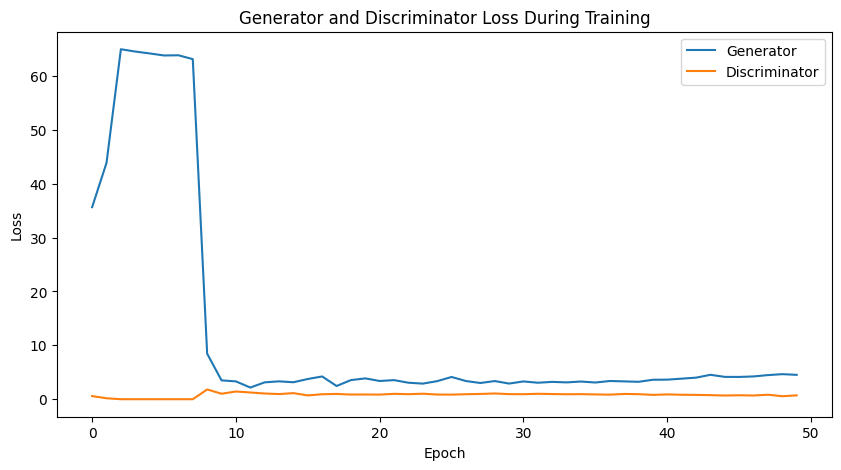

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(epoch_g_losses, label="Generator")
plt.plot(epoch_d_losses, label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Save loss plot
try:
    loss_plot_path = os.path.join(base_dir, "training_losses.png")
    plt.savefig(loss_plot_path)
    print(f"✓ Loss plot saved to {loss_plot_path}")
except Exception as e:
    print(f"❌ Error saving loss plot: {str(e)}")

plt.show()


In [11]:
# Generate final images
with torch.no_grad():
    sample_noise = torch.randn(64, latent_dim, 1, 1, device=device)
    sample_images = generator(sample_noise).detach().cpu()

    grid = vutils.make_grid(sample_images, nrow=8, padding=2, normalize=True)
    final_sample_path = os.path.join(gen_images_dir, "final_samples2.png")
    save_image(grid, final_sample_path)

print(f"✓ Final samples saved to {final_sample_path}")


✓ Final samples saved to /Users/lucas/Documents/MIA/1ANO/2SEM/ACPR/generated_images/final_samples2.png
